Plant Disease Detection

Importing desired libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
tf.compat.v1.set_random_seed(0)
from tensorflow import keras
import numpy as np
np.random.seed(0)
import itertools
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json manually


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanjayg10","key":"023e828726d253621891ecea0c9a70c9"}'}

In [3]:
import os
import zipfile

# Move kaggle.json to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 98% 2.64G/2.70G [00:20<00:01, 38.8MB/s]
100% 2.70G/2.70G [00:20<00:00, 142MB/s] 


In [5]:
!ls /content


kaggle.json  new-plant-diseases-dataset.zip  sample_data


Downloading zipfile and unzipping

In [6]:
import zipfile

zip_path = "new-plant-diseases-dataset.zip"
extract_to = "plant_disease_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset unzipped.")




✅ Dataset unzipped.


In [7]:
import os

# Step 1: Detect the correct nested dataset folder
root_path = "plant_disease_data"
first_level = os.path.join(root_path, os.listdir(root_path)[1])
second_level = os.path.join(first_level, os.listdir(first_level)[0])  # deeper folder

print("✅ Actual dataset folder:", second_level)
print("Contents:", os.listdir(second_level))  # should show ['train', 'test']



✅ Actual dataset folder: plant_disease_data/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
Contents: ['valid', 'train']


moving training and testing datasets

In [8]:
import shutil

# Set source paths
train_src = os.path.join(second_level, "train")
test_src = os.path.join(second_level, "valid")

# Set destination paths
train_dst = "/content/train"
test_dst = "/content/valid"

# Move the folders
shutil.move(train_src, train_dst)
shutil.move(test_src, test_dst)

print("✅ Moved train and test folders successfully!")

✅ Moved train and test folders successfully!


In [9]:
print("Train classes:", os.listdir(train_dst)[:5])
print("Test classes:", os.listdir(test_dst)[:5])


Train classes: ['Strawberry___healthy', 'Grape___Esca_(Black_Measles)', 'Tomato___Tomato_mosaic_virus', 'Pepper,_bell___healthy', 'Grape___healthy']
Test classes: ['Strawberry___healthy', 'Grape___Esca_(Black_Measles)', 'Tomato___Tomato_mosaic_virus', 'Pepper,_bell___healthy', 'Grape___healthy']


In [10]:
new_first_level=os.path.join(root_path, os.listdir(root_path)[0])
new_second_level = os.path.join(new_first_level, os.listdir(new_first_level)[0])  # deeper folder
print(new_first_level)
print(new_second_level)
print(os.listdir(new_first_level))

plant_disease_data/test
plant_disease_data/test/test
['test']


In [11]:
final_test_src = os.path.join(new_first_level, "test")
final_test_dst="/content/test"
shutil.move(final_test_src,final_test_dst)

'/content/test'

defining the CNN

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [13]:
IMG_SIZE = (128, 128)  # resize all images
BATCH_SIZE = 32


In [14]:
train_datagen = ImageDataGenerator(rescale=1./255)   #rescales pixel values between 0 and 1
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(       #creates a directory iterator
    train_dst,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='categorical'  # use 'binary' for 2-class (here is is one hot encoded)
)

test_gen = test_datagen.flow_from_directory(
    test_dst,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [34]:
print(train_gen[0])

(array([[[[0.6627451 , 0.64705884, 0.77647066],
         [0.654902  , 0.6392157 , 0.7686275 ],
         [0.654902  , 0.6392157 , 0.7686275 ],
         ...,
         [0.7411765 , 0.7294118 , 0.8431373 ],
         [0.7294118 , 0.7176471 , 0.8313726 ],
         [0.7176471 , 0.7058824 , 0.8196079 ]],

        [[0.65882355, 0.6431373 , 0.7725491 ],
         [0.6509804 , 0.63529414, 0.76470596],
         [0.64705884, 0.6313726 , 0.7607844 ],
         ...,
         [0.7372549 , 0.7254902 , 0.83921576],
         [0.7372549 , 0.7254902 , 0.83921576],
         [0.73333335, 0.72156864, 0.8352942 ]],

        [[0.67058825, 0.654902  , 0.7843138 ],
         [0.6745098 , 0.65882355, 0.78823537],
         [0.6745098 , 0.65882355, 0.78823537],
         ...,
         [0.7294118 , 0.7176471 , 0.8313726 ],
         [0.7294118 , 0.7176471 , 0.8313726 ],
         [0.7294118 , 0.7176471 , 0.8313726 ]],

        ...,

        [[0.41176474, 0.37254903, 0.5058824 ],
         [0.39607847, 0.35686275, 0.4901961 

In [15]:
print("Classes:", train_gen.class_indices.keys())
#to check if healthy is there in name

Classes: dict_keys(['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 

Building the CNN Model

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_gen.class_indices), activation='softmax')  # One output per class
])


In [17]:
#compiling a model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Using early stops and training epochs

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',       # or 'val_accuracy'
    patience=3,               # wait 3 epochs after no improvement
    restore_best_weights=True  # restore best weights (optional but recommended)
)

In [39]:
#training the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/20
2197/2197 - 93s - 42ms/step - accuracy: 0.9126 - loss: 0.2639 - val_accuracy: 0.9090 - val_loss: 0.3199
Epoch 2/20
2197/2197 - 98s - 45ms/step - accuracy: 0.9188 - loss: 0.2411 - val_accuracy: 0.9009 - val_loss: 0.3635
Epoch 3/20
2197/2197 - 98s - 45ms/step - accuracy: 0.9219 - loss: 0.2347 - val_accuracy: 0.8858 - val_loss: 0.4039
Epoch 4/20
2197/2197 - 95s - 43ms/step - accuracy: 0.9281 - loss: 0.2118 - val_accuracy: 0.9087 - val_loss: 0.3454


Determining if plant is healthy or not

In [40]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_plant_health(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred[0])
    class_name = list(train_gen.class_indices.keys())[class_idx]

    if "healthy" in class_name.lower():
        print("🌱 Plant is Healthy")
    else:
        print(f"⚠️ Plant is Unhealthy — Disease: {class_name.split('___')[-1]}")
    return class_name


Metrics

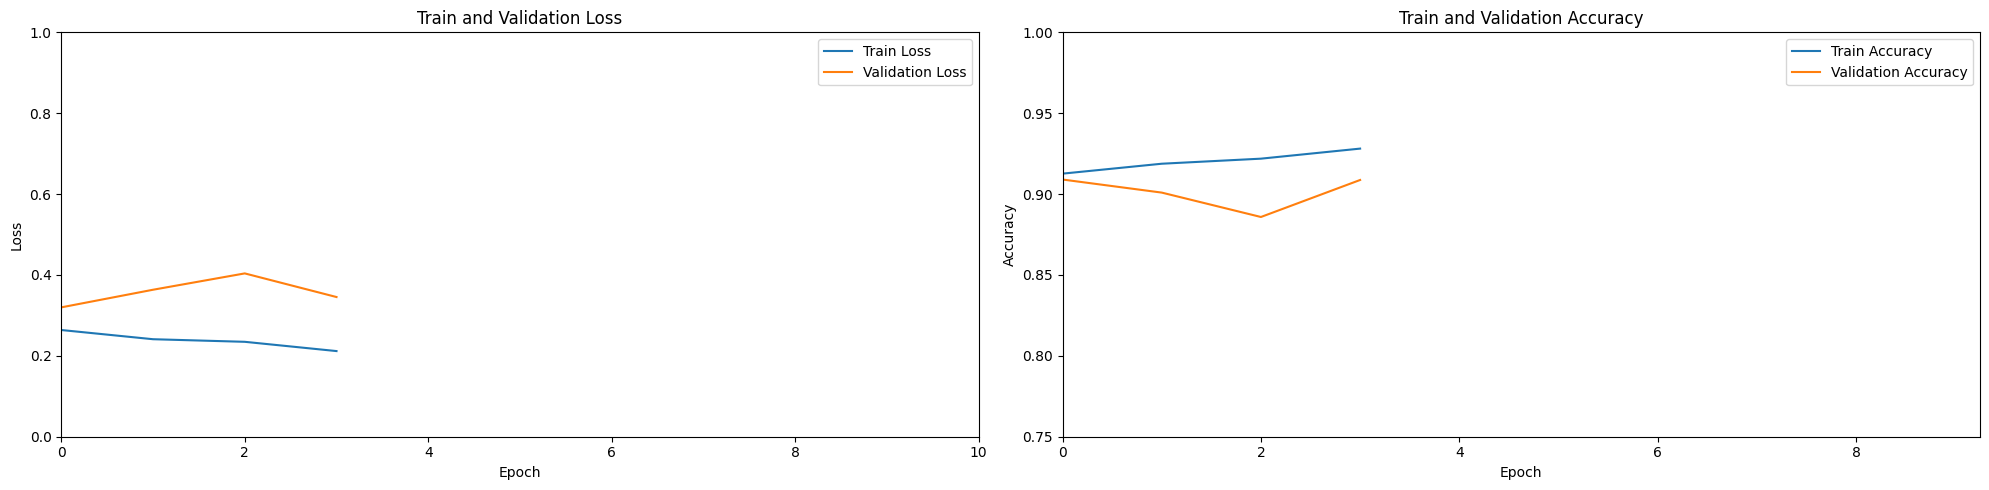

In [42]:
plt.figure(figsize = (20,5))
plt.subplot(1,2,1)
#plotting loss over epochs
plt.title("Train and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlim(0, 10)
plt.ylim(0.0,1.0)
plt.legend()

#plotting accuracy over epochs
plt.subplot(1,2,2)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlim(0, 9.25)
plt.ylim(0.75,1.0)
plt.legend()
plt.tight_layout()


In [43]:
model.save("plant_disease_model.h5")
#we are saving this model

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


In [45]:
# Get ground truth labels and file count
true_labels = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Predict on all test data
pred_probs = model.predict(test_gen, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)


550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step


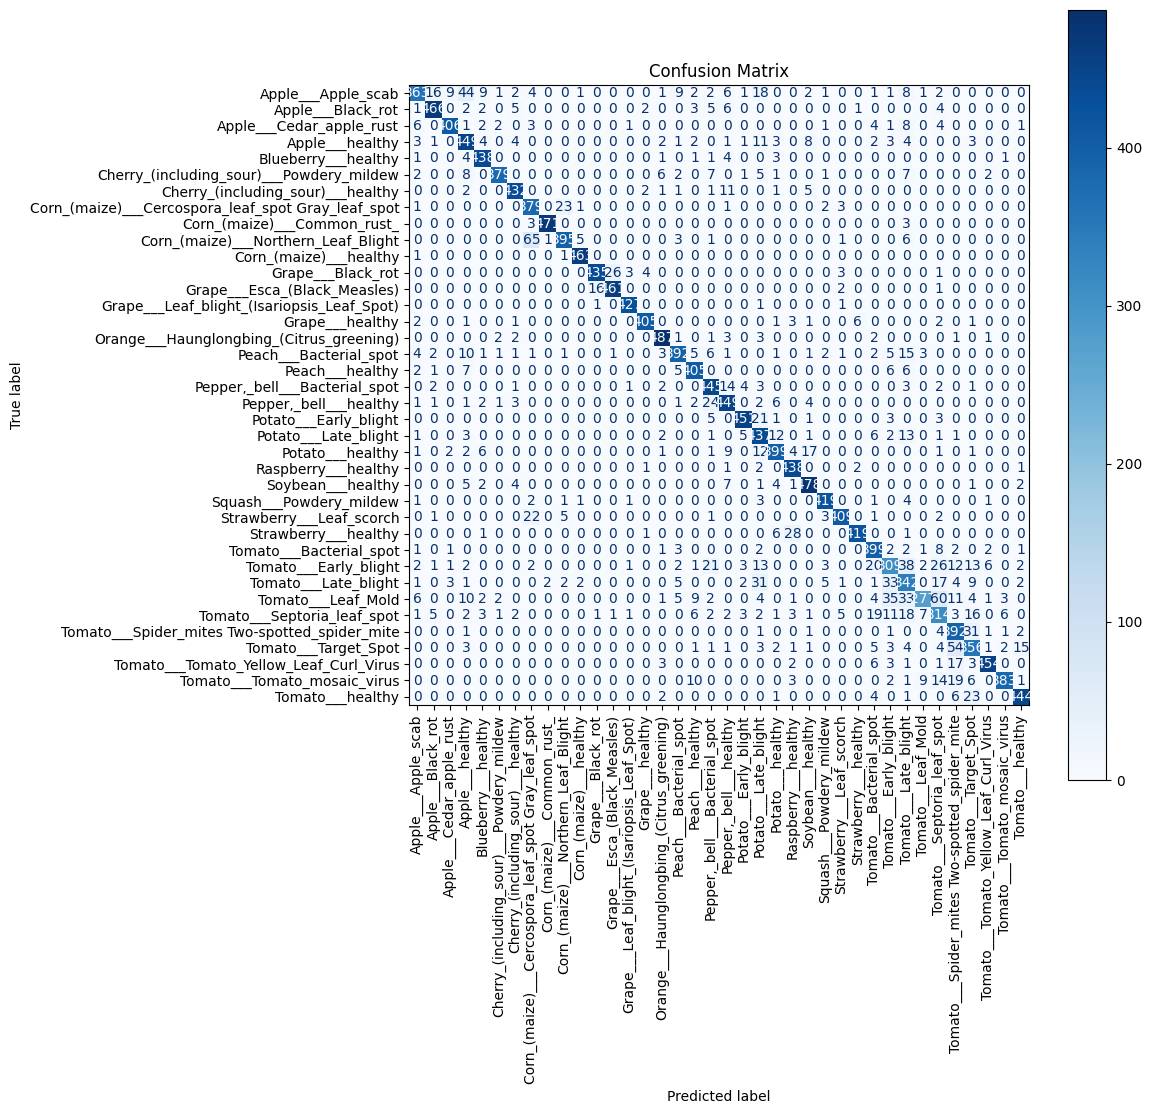

In [26]:
#confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [27]:
#accuracy report
print("📋 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_labels))


📋 Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.72      0.80       504
                                 Apple___Black_rot       0.94      0.94      0.94       497
                          Apple___Cedar_apple_rust       0.96      0.92      0.94       440
                                   Apple___healthy       0.80      0.89      0.85       502
                               Blueberry___healthy       0.93      0.96      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.97      0.90      0.94       421
                 Cherry_(including_sour)___healthy       0.95      0.95      0.95       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.92      0.85       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight   

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ----------- TRAIN ACCURACY ------------
# If you want to evaluate on training set as well:
train_loss, train_acc = model.evaluate(train_gen, verbose=0)

# ----------- TEST ACCURACY ------------
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

# ----------- PREDICTIONS & TRUE LABELS ------------
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# ----------- PRECISION & RECALL ------------
precision = precision_score(y_true, y_pred, average='macro')  # use 'weighted' if imbalance
recall = recall_score(y_true, y_pred, average='macro')

# ----------- PRINT RESULTS ------------
print(f"\n🟢 Train Accuracy  : {train_acc * 100:.2f} %")
print(f"🔵 Test Accuracy   : {test_acc * 100:.2f} %")
print(f"🟡 Precision Score : {precision * 100:.2f} %")
print(f"🟠 Recall Score    : {recall * 100:.2f} %")


550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step

🟢 Train Accuracy  : 99.11 %
🔵 Test Accuracy   : 90.90 %
🟡 Precision Score : 91.11 %
🟠 Recall Score    : 90.89 %


In [29]:
for img_name in os.listdir(final_test_dst):
  img_path = os.path.join(final_test_dst, img_name)
  predict_plant_health(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
⚠️ Plant is Unhealthy — Disease: Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
⚠️ Plant is Unhealthy — Disease: Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
⚠️ Plant is Unhealthy — Disease: Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
⚠️ Plant is Unhealthy — Disease: Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
🌱 Plant is Healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
⚠️ Plant is Unhealthy — Disease: Cedar_apple_rust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
⚠️ Plant is Unhealthy — Disease: Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
⚠️ Plant is Unhealthy — Disease: Bacterial_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
⚠️ Plant is Unhealthy — Disease: Spider_mites Two-spotted_spider_mite
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
🌱 Plant is Healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
⚠️ Plant is Unhealthy — Disease: Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
⚠️ Plant is

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
⚠️ Plant is Unhealthy — Disease: Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
⚠️ Plant is Unhealthy — Disease: Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
⚠️ Plant is Unhealthy — Disease: Tomato_Yellow_Leaf_Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
⚠️ Plant is Unhealthy — Disease: Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
🌱 Plant is Healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
⚠️ Plant is Unhealthy — Disease: Cedar_apple_rust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
⚠️ Plant is Unhealthy — Disease: Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
⚠️ Plant is Unhealthy — Disease: Bacterial_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
⚠️ Plant is Unhealthy — Disease: Spider_mites Two-spotted_spider_mite


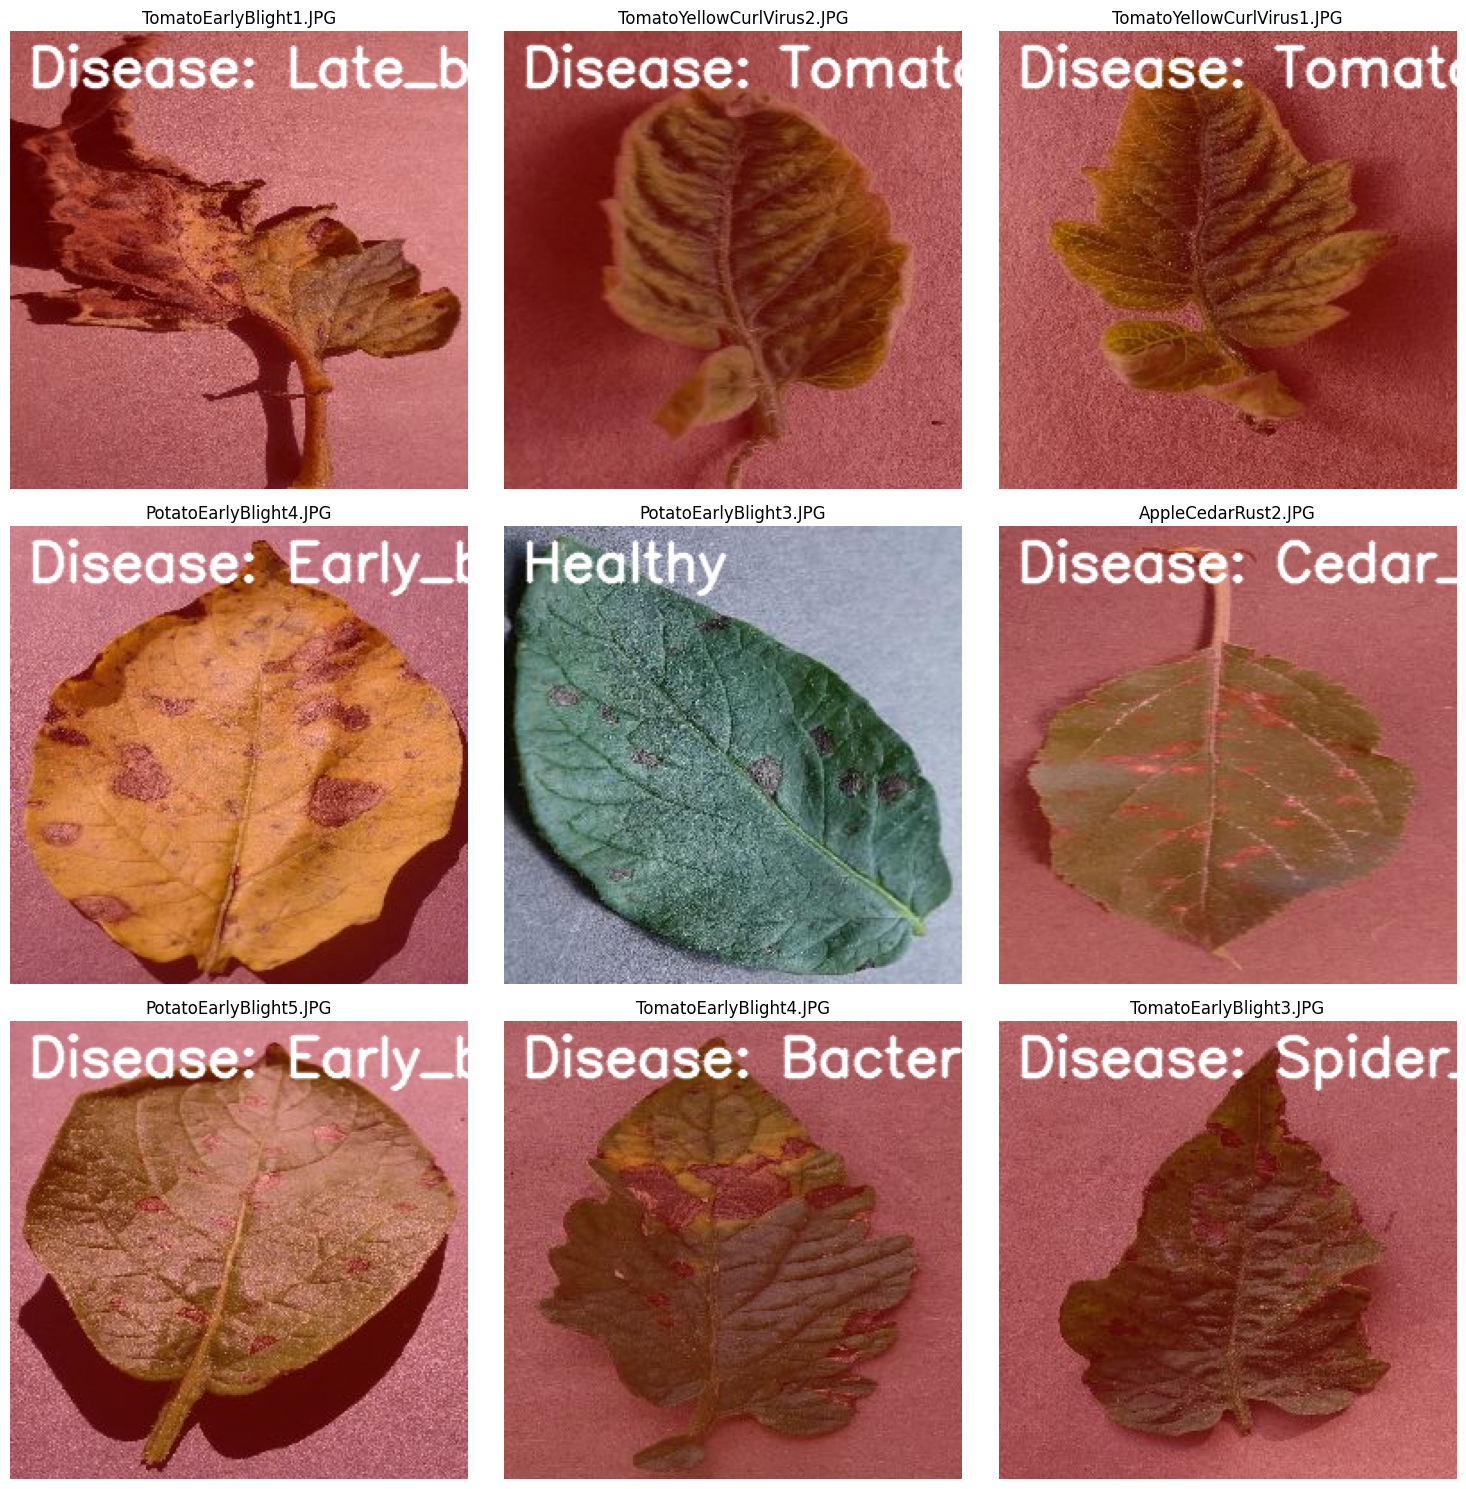

In [32]:
from glob import glob
import cv2
# Path to test images
test_dir = "/content/test"
image_paths = glob(os.path.join(test_dir, "*.*"))

# Displaying results
plt.figure(figsize=(15, 15))

for idx, img_path in enumerate(image_paths):
    # Load and convert image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get prediction
    class_name = predict_plant_health(img_path)

    # Extract disease name from class (e.g., "Plant___DiseaseX" → "DiseaseX")
    if "healthy" in class_name.lower():
        blended = img_rgb  # No mask for healthy
        label_text = "Healthy"
    else:
        disease = class_name.split("___")[-1]
        label_text = f"Disease: {disease}"

        # Red overlay mask for disease
        overlay = img_rgb.copy()
        overlay[:] = (255, 0, 0)  # Pure red
        blended = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)

    # Add label text
    cv2.putText(blended, f"{label_text}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                1, (255, 255, 255), 2, cv2.LINE_AA)

    # Show in grid
    plt.subplot(3, 3, idx + 1)
    plt.imshow(blended)
    plt.axis("off")
    plt.title(os.path.basename(img_path))

    if idx >= 8:
        break

plt.tight_layout()
plt.show()